Importing libraries


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Read csv file

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\car_prediction_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Finding null values

In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

info for checking dtypes

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


describe for finding outliers

In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


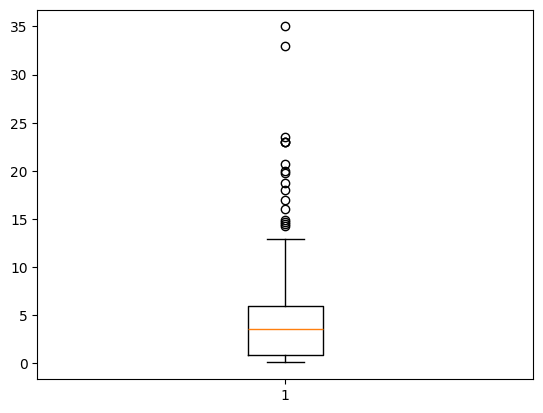

In [7]:
plt.boxplot(df['Selling_Price'])
plt.show()

Removing outliers

In [8]:
max(df['Selling_Price'])

35.0

In [9]:
df = df[df['Selling_Price'] < 12]

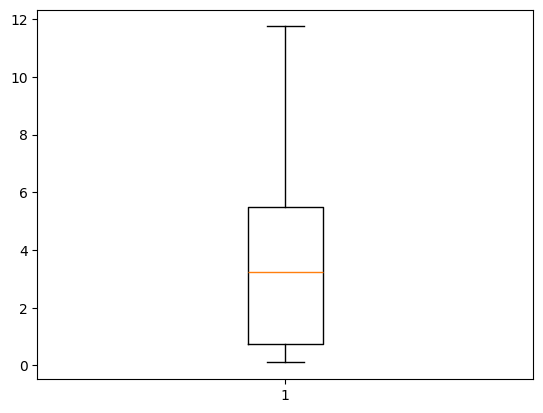

In [10]:
plt.boxplot(df['Selling_Price'])
plt.show()

for encoding finding column's unique values

In [11]:
df['Transmission'].unique(), df['Fuel_Type'].unique(),df['Seller_Type'].unique()

(<StringArray>
 ['Manual', 'Automatic']
 Length: 2, dtype: str,
 <StringArray>
 ['Petrol', 'Diesel', 'CNG']
 Length: 3, dtype: str,
 <StringArray>
 ['Dealer', 'Individual']
 Length: 2, dtype: str)

Encoding categorical data

In [12]:
categorical_column = df[['Transmission', 'Fuel_Type', 'Seller_Type']]
for col in categorical_column:
    df[col] = df[col].map({
        'Manual':0,
        'Automatic':1,
        'Petrol':0,
        'Diesel':1,
        'CNG':2,
        'Dealer':0,
        'Individual':1,
    })

In [13]:
le = LabelEncoder()
df['Car_Name'] = le.fit_transform(df['Car_Name'])

In [14]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,89,2014,3.35,5.59,27000,0,0,0,0
1,92,2013,4.75,9.54,43000,1,0,0,0
2,68,2017,7.25,9.85,6900,0,0,0,0


creating feature and target data

In [15]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

Dividing data into training and testing data

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Train model with training data

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model prediction

In [18]:
y_pred = model.predict(X_test)
y_pred = y_pred.astype(int)

Checking accuracy of model

In [19]:
model.score(X_train, y_train), model.score(X_test, y_test)

(0.8413018403441438, 0.8149389953178404)

Comparing actual and predicted data

In [20]:
Comparision = pd.DataFrame({
    'Actual Price' : y_test,
    'Predicted Price': y_pred
})
Comparision.head()

,Actual Price,Predicted Price
110,1.20,1
111,1.15,1
197,0.16,0
142,0.60,1
280,5.25,4


Predicting new car prices with the model

In [21]:
new_car = [[89,2014,5.59,27000,0,0,0,0]]
predicted_price = model.predict(new_car)
print(predicted_price)  #3.35

[4.00265461]


c:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Actual vs Predicted Price Graph Plot

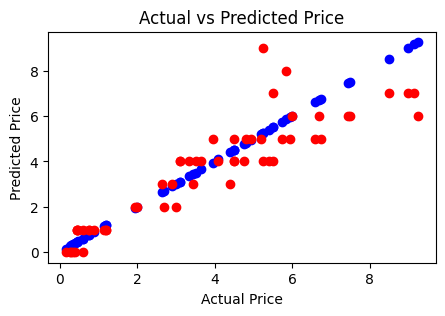

In [22]:
plt.figure(figsize=(5,3))
plt.scatter(y_test, y_test, color='blue', label='Actual Price')
plt.scatter(y_test, y_pred, color='red', label='Predicted Price')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()